In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.style.use("ggplot")

In [18]:
df = pd.read_csv(
    "../data/processed/clean_jobs.csv"
)

df.head()

,job_id,job_title,company_size,company_industry,country,remote_type,experience_level,years_experience,education_level,skills_python,...,skills_ml,skills_deep_learning,skills_cloud,salary,job_posting_month,job_posting_year,hiring_urgency,job_openings,total_skills,posting_date
0,1,AI Engineer,Startup,Retail,Canada,Remote,Senior,2,Master,0,...,0,1,0,158322,6,2024,Low,4,1,6-2024
1,2,Machine Learning Engineer,MNC,Technology,Australia,Hybrid,Mid,0,Bachelor,1,...,1,0,1,163666,11,2026,High,9,4,11-2026
2,3,Machine Learning Engineer,MNC,Technology,Germany,Onsite,Mid,14,Master,1,...,1,0,1,158556,3,2026,High,9,3,3-2026
3,4,Business Analyst,Startup,Healthcare,Germany,Remote,Mid,9,Master,0,...,0,1,1,95775,3,2025,High,7,3,3-2025
4,5,Data Scientist,MNC,Healthcare,Germany,Hybrid,Mid,5,Master,1,...,1,0,0,111873,12,2021,Low,2,3,12-2021


In [19]:
salary_country = (
    df.groupby("country")["salary"]
      .mean()
      .sort_values(
          ascending=False
      )
)

salary_country.head(10)

country
Canada       114782.863575
Singapore    114541.380537
Australia    114367.358763
USA          113280.956134
UK           112722.327946
India        112447.391156
Germany      111938.023364
Name: salary, dtype: float64

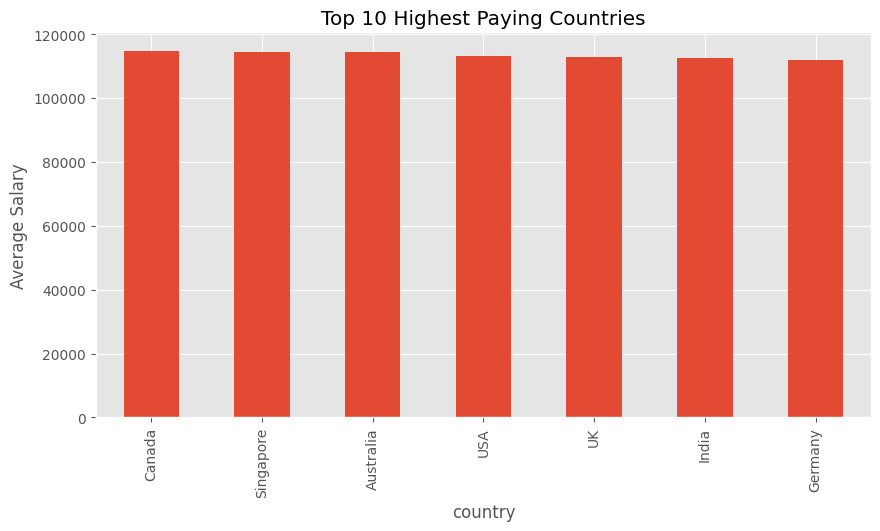

In [20]:
plt.figure(figsize=(10,5))

salary_country.head(10).plot(
    kind="bar"
)

plt.title(
    "Top 10 Highest Paying Countries"
)

plt.ylabel(
    "Average Salary"
)

plt.show()

In [21]:
salary_country.reset_index().to_json(
    "../data/processed/salary_country.json",
    orient="records"
)

In [22]:
experience_salary = (
    df.groupby("experience_level")
      ["salary"]
      .mean()
      .sort_values()
)

experience_salary

experience_level
Entry      89095.872758
Mid       113592.018464
Senior    138289.091520
Name: salary, dtype: float64

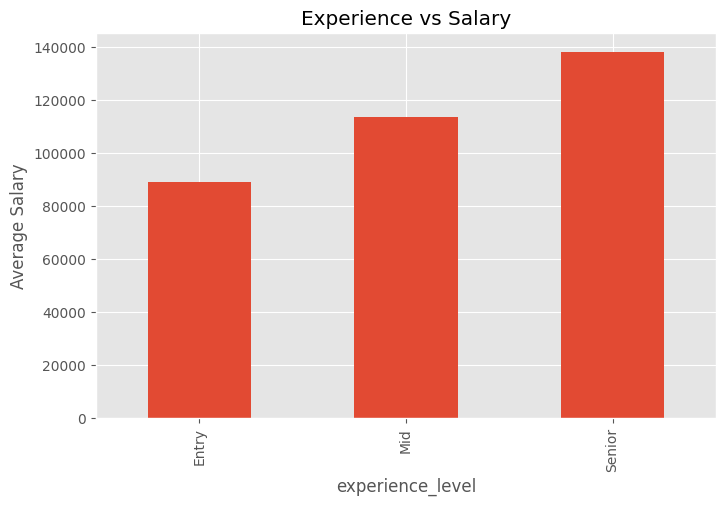

In [23]:
plt.figure(figsize=(8,5))

experience_salary.plot(
    kind="bar"
)

plt.title(
    "Experience vs Salary"
)

plt.ylabel(
    "Average Salary"
)

plt.show()

In [24]:
experience_salary.reset_index().to_json(
    "../data/processed/experience_salary.json",
    orient="records"
)

In [25]:
remote_salary = (
    df.groupby("remote_type")
      ["salary"]
      .mean()
      .sort_values(
          ascending=False
      )
)

remote_salary

remote_type
Onsite    113649.938453
Hybrid    113363.757018
Remote    113305.101623
Name: salary, dtype: float64

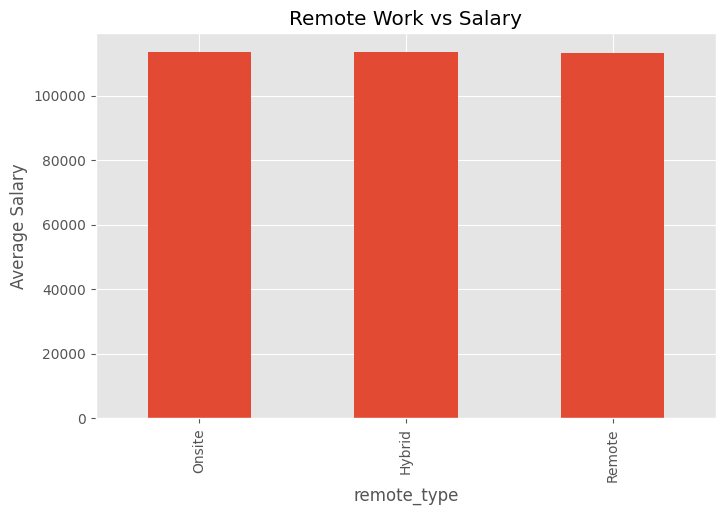

In [26]:
plt.figure(figsize=(8,5))

remote_salary.plot(
    kind="bar"
)

plt.title(
    "Remote Work vs Salary"
)

plt.ylabel(
    "Average Salary"
)

plt.show()

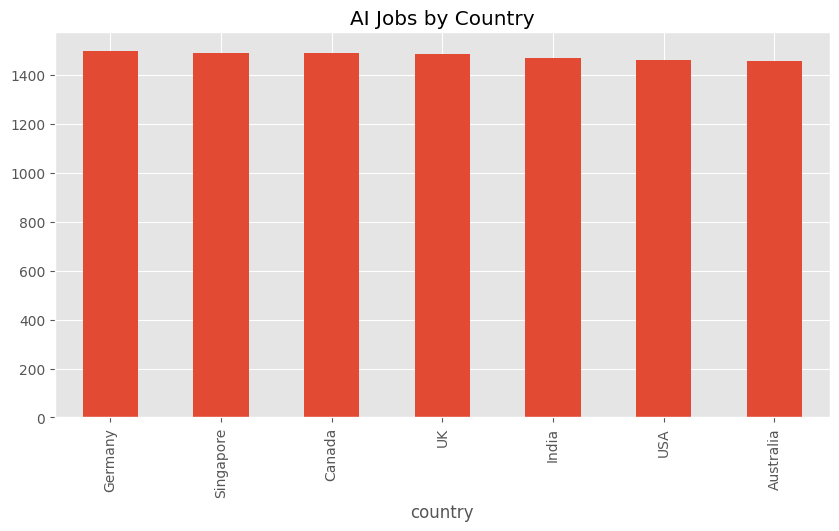

In [27]:
country_jobs.head(10).plot(
    kind="bar",
    figsize=(10,5),
    title="AI Jobs by Country"
)

plt.show()

In [28]:
remote_salary.reset_index().to_json(
    "../data/processed/remote_salary.json",
    orient="records"
)

In [29]:
skill_salary = {
    "Python":
        df[df["skills_python"] == 1]
        ["salary"].mean(),

    "SQL":
        df[df["skills_sql"] == 1]
        ["salary"].mean(),

    "ML":
        df[df["skills_ml"] == 1]
        ["salary"].mean(),

    "Deep Learning":
        df[df["skills_deep_learning"] == 1]
        ["salary"].mean(),

    "Cloud":
        df[df["skills_cloud"] == 1]
        ["salary"].mean()
}

skill_salary

{'Python': np.float64(113741.7051558518),
 'SQL': np.float64(113329.868754804),
 'ML': np.float64(120625.52303007232),
 'Deep Learning': np.float64(121080.09666149068),
 'Cloud': np.float64(118154.0102060102)}

In [30]:
skill_df = pd.DataFrame(
    skill_salary.items(),
    columns=[
        "skill",
        "avg_salary"
    ]
)

skill_df

,skill,avg_salary
0,Python,113741.705156
1,SQL,113329.868755
2,ML,120625.523030
3,Deep Learning,121080.096661
4,Cloud,118154.010206


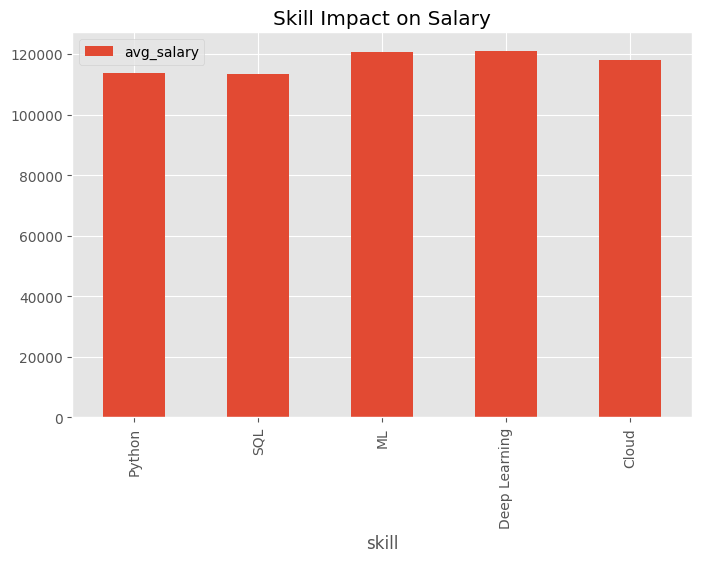

In [31]:
skill_df.plot(
    x="skill",
    y="avg_salary",
    kind="bar",
    figsize=(8,5)
)

plt.title(
    "Skill Impact on Salary"
)

plt.show()

In [32]:
skill_df.to_json(
    "../data/processed/skill_salary.json",
    orient="records"
)

In [33]:
urgency = (
    df.groupby(
        "hiring_urgency"
    )
    ["job_openings"]
    .sum()
)

urgency

hiring_urgency
High      33940
Low        9625
Medium     8202
Name: job_openings, dtype: int64

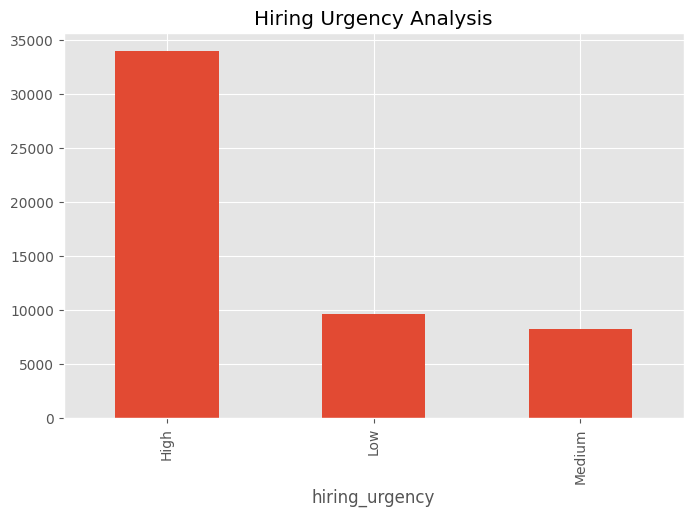

In [34]:
urgency.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title(
    "Hiring Urgency Analysis"
)

plt.show()

In [35]:
urgency.reset_index().to_json(
    "../data/processed/hiring_urgency.json",
    orient="records"
)

In [36]:
from sklearn.linear_model import LinearRegression

In [37]:
pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [38]:
yearly_jobs = (
    df.groupby(
        "job_posting_year"
    )
    .size()
    .reset_index(
        name="jobs"
    )
)

yearly_jobs

,job_posting_year,jobs
0,2020,1468
1,2021,1480
2,2022,1494
3,2023,1454
4,2024,1502
5,2025,1481
6,2026,1466


In [39]:
X = yearly_jobs[
    ["job_posting_year"]
]

y = yearly_jobs["jobs"]

model = LinearRegression()

model.fit(X, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [40]:
future_years = pd.DataFrame(
    {
        "job_posting_year":
        [2027, 2028, 2029, 2030]
    }
)

predictions = model.predict(
    future_years
)

forecast = pd.DataFrame(
    {
        "year":
        future_years[
            "job_posting_year"
        ],

        "predicted_jobs":
        predictions.astype(int)
    }
)

forecast

,year,predicted_jobs
0,2027,1478
1,2028,1478
2,2029,1478
3,2030,1478


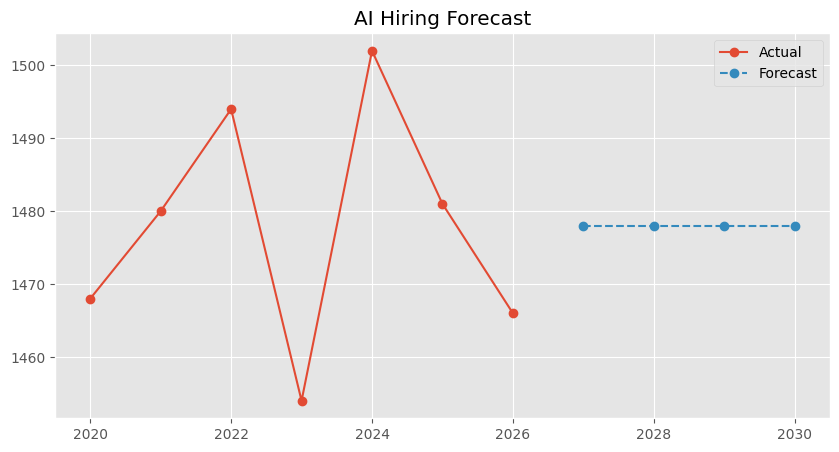

In [41]:
plt.figure(figsize=(10,5))

plt.plot(
    yearly_jobs[
        "job_posting_year"
    ],
    yearly_jobs["jobs"],
    marker="o",
    label="Actual"
)

plt.plot(
    forecast["year"],
    forecast[
        "predicted_jobs"
    ],
    marker="o",
    linestyle="--",
    label="Forecast"
)

plt.legend()

plt.title(
    "AI Hiring Forecast"
)

plt.show()

In [42]:
forecast.to_json(
    "../data/processed/forecast.json",
    orient="records"
)